<a href="https://colab.research.google.com/github/PhyTorch/Machine-Learning-Lecture/blob/main/Research_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [1]:
import numpy as np

# Insert your values
Name = "Haoyang Jiang" # Replace with your name
CID = 2213534 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of Haoyang Jiang [CID: 2213534]

Your challenge code is D


## Problem statement

You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

I am solving the matbench_glass task from Matbench v0.1. This is a composition-only binary classification problem where the input is chemical formula and the target variable `gfa` indicates whether a composition forms a bulk metallic glass. The official benchmark metric is ROC-AUC, and the current best public result on this task is MODNet v0.1.12 (a feed-forward neural network) with mean ROC-AUC 0.9603.

## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [28]:
# Installation of libraries
!pip install matminer==0.9.3 --quiet
!pip install pymatgen --quiet
!pip install torch --quiet
!pip install scikit-optimize --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.7 MB/s eta 0:00:00


In [29]:
# Import of modules
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from pymatgen.core import Composition

from matminer.datasets import load_dataset, get_all_dataset_info
from matminer.featurizers.composition import ElementProperty, Stoichiometry

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
  roc_auc_score,
  roc_curve,
  accuracy_score,
  balanced_accuracy_score,
  f1_score,
  confusion_matrix,
  ConfusionMatrixDisplay
)

from skopt import gp_minimize
from skopt.space import Integer, Real

plt.style.use("ggplot")

In [30]:
# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
#info = get_all_dataset_info("matbench_expt_gap")

  # C
#info = get_all_dataset_info("matbench_expt_is_metal")

  # D
info = get_all_dataset_info("matbench_glass")

  # E
#info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_glass
Description: Matbench v0.1 test dataset for predicting full bulk metallic glass formation ability from chemical formula. Retrieved from "Nonequilibrium Phase Diagrams of Ternary Amorphous Alloys,’ a volume of the Landolt– Börnstein collection. Deduplicated according to composition, ensuring no compositions were reported as both GFA and not GFA (i.e., all reports agreed on the classification designation). For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	gfa: Target variable. Glass forming ability: 1 means glass forming and corresponds to amorphous, 0 means non full glass forming.
Num Entries: 5680
Reference: Y. Kawazoe, T. Masumoto, A.-P. Tsai, J.-Z. Yu, T. Aihara Jr. (1997) Y. Kawazoe, J.-Z. Yu, A.-P. Tsai, T. Masumoto (ed.) SpringerMaterials
Nonequilibrium Phase Diagrams of Ternary Amorphous All

In [31]:
# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_glass")

print(f"The full dataset contains {df.shape[0]} entries.\n")
print("The DataFrame is shown below:")
print(df)

The full dataset contains 5680 entries.

The DataFrame is shown below:
      composition    gfa
0              Al  False
1        Al(NiB)2   True
2     Al10Co21B19   True
3     Al10Co23B17   True
4     Al10Co27B13   True
...           ...    ...
5675        ZrTi9  False
5676      ZrTiSi2   True
5677      ZrTiSi3   True
5678       ZrVCo8   True
5679       ZrVNi2   True

[5680 rows x 2 columns]


In [32]:
# Inspect the dataset
print("Columns in the dataset:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass counts:")
print(df["gfa"].value_counts())

print("\nClass fractions:")
print(df["gfa"].value_counts(normalize=True))

Columns in the dataset:
Index(['composition', 'gfa'], dtype='object')

Missing values:
composition    0
gfa            0
dtype: int64

Class counts:
gfa
True     4035
False    1645
Name: count, dtype: int64

Class fractions:
gfa
True     0.710387
False    0.289613
Name: proportion, dtype: float64


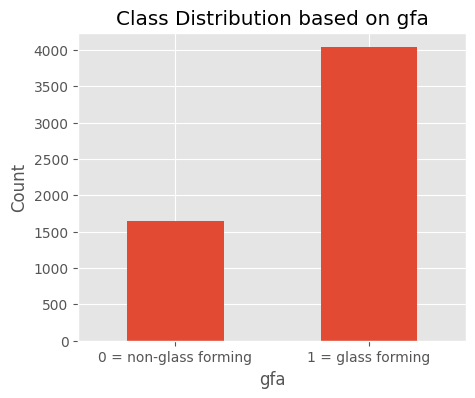

In [33]:
# Plot class balance
plt.figure(figsize=(5, 4))
df["gfa"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["0 = non-glass forming", "1 = glass forming"], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution based on gfa")
plt.show()

I featurised the compositions using both elemental-property statistics and stoichiometric information because they capture different aspects of a material. Using both will give the neural network a richer input representation and helps the model to capture both the chemical chracter and the proportional structure of the composition.

In [34]:
# Convert strings to pymatgen Composition objects
df = df.copy()
df["composition_obj"] = df["composition"].apply(Composition)

In [35]:
# Featurise composition
ep_feat = ElementProperty.from_preset("magpie")
st_feat = Stoichiometry()

df_feat = ep_feat.featurize_dataframe(
  df,
  col_id="composition_obj",
  ignore_errors=True,
  pbar=True
)

df_feat = st_feat.featurize_dataframe(
  df_feat,
  col_id="composition_obj",
  ignore_errors=True,
  pbar=True
)

print("Featurised DataFrame shape:", df_feat.shape)

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/5680 [00:00<?, ?it/s]

Stoichiometry:   0%|          | 0/5680 [00:00<?, ?it/s]

Featurised DataFrame shape: (5680, 141)


In [36]:
# Build feature matrix and target vector
cols_to_drop = ["composition", "composition_obj", "gfa"]
X_df = df_feat.drop(columns=cols_to_drop, errors="ignore")
X_df = X_df.select_dtypes(include=[np.number])
X_df = X_df.replace([np.inf, -np.inf], np.nan)

y = df_feat["gfa"].astype(np.float32).values

print("Feature matrix shape:", X_df.shape)
print("Target shape:", y.shape)

Feature matrix shape: (5680, 138)
Target shape: (5680,)


The imputer and scaler must be fit on training data only, then applied to validation/test data. That avoids leakage.

`StandardScaler` is especially important for FFNNs because they are sensitive to feature scale.

In [37]:
def preprocess_split(X_train_df, X_val_df, X_test_df):
  imputer = SimpleImputer(strategy="median")
  scaler = StandardScaler()

  X_train = imputer.fit_transform(X_train_df)
  X_val = imputer.transform(X_val_df)
  X_test = imputer.transform(X_test_df)

  X_train = scaler.fit_transform(X_train)
  X_val = scaler.transform(X_val)
  X_test = scaler.transform(X_test)

  return X_train, X_val, X_test, imputer, scaler

Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

In [38]:
# DataLoader
def make_loader(X_array, y_array, batch_size=64, shuffle=False):
  """
  Convert NumPy feature and target arrays into a PyTorch DataLoader.

  Parameters:
  X_array: numpy.ndarray
      Feature matrix of shape (n_samples, n_features).
  y_array: numpy.ndarray
      Binary target array of shape (n_samples,).
  batch_size: int, default=64
      Number of samples per batch.
  shuffle: bool, default=False
      Whether to shuffle the data at the start of each epoch.

  Returns:
  DataLoader containing tensor-converted features and targets.
  """
  X_tensor = torch.tensor(X_array, dtype=torch.float32)
  y_tensor = torch.tensor(y_array, dtype=torch.float32).view(-1, 1)
  dataset = TensorDataset(X_tensor, y_tensor)
  return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [39]:
# Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### Model choice

I chose a feed-forward neural network (FFNN) for this task because the input data are chemical compositions which can be represented as fixed-length numerical vectors, which are suitable for a neural network.

This makes the FFNN a suitable model for learning nonlinear relationships between composition-derived descriptors and the binary target gfa. Compared with a single linear model, a multi-layer network can capture interactions between descriptors such as elemental-property statistics and stoichiometric information.

Moreover, the current best-performing benchmark for the problem, MODNet, is a FFNN, which makes FFNN an idela choice of model to solve the problem.

I use a single-logit output because it is a binary classification problem. I trianed the model with `BCEWithLogitsLoss` for binary targets and used `pos_weight` to reduce the effect of target class imbalance.

In [40]:
# Define the FFNN model
class FeedForwardNN(nn.Module):
  def __init__(self, input_dim, hidden_dims=[256, 128], dropout=0.2):
    """
    Feed-forward neural network for binary classification on tabular features.

    The network consists of a stack of fully connected layers with ReLU
    activation and dropout regularisation, followed by a single output neuron
    that produces a logit for binary classification.

    Parameters
    input_dim: int
        Number of input features.
    hidden_dims: tuple of int, default=(256, 128)
        Sizes of the hidden layers.
    dropout: float, default=0.2
        Dropout probability applied after each hidden layer.
    """
    super().__init__()

    layers = []
    prev_dim = input_dim

    for hidden_dim in hidden_dims:
      layers.append(nn.Linear(prev_dim, hidden_dim))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout))
      prev_dim = hidden_dim

    layers.append(nn.Linear(prev_dim, 1))  # single logit output

    self.network = nn.Sequential(*layers)

  def forward(self, x):
    """
    Perform a forward pass through the network.

    Parameters
    x: torch.Tensor
      Input tensor of shape (batch_size, input_dim).

    Returns
    torch.Tensor:
      Output logits of shape (batch_size, 1).
    """
    return self.network(x)

In [41]:
# Evaluation function
def evaluate_model(model, data_loader, criterion):
  """
  Evaluate a trained model on a dataset.

  This function computes the mean loss and ROC-AUC score, and also returns
  the true labels and predicted probabilities for downstream analysis.

  Parameters
  model: torch.nn.Module
    Trained PyTorch model.
  data_loader: torch.utils.data.DataLoader
    DataLoader containing evaluation data.
  criterion: torch.nn.Module
    Loss function used for evaluation.

  Returns
  mean_loss: float
    Average loss over the dataset.
  roc_auc: float
    ROC-AUC score computed from predicted probabilities.
  y_true: numpy.ndarray
    True binary labels.
  y_score: numpy.ndarray
    Predicted probabilities for the positive class.
  """
  model.eval()

  total_loss = 0.0
  y_true = []
  y_score = []

  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      logits = model(X_batch)
      loss = criterion(logits, y_batch)

      total_loss += loss.item() * len(y_batch)

      probs = torch.sigmoid(logits)
      y_true.extend(y_batch.cpu().numpy().ravel())
      y_score.extend(probs.cpu().numpy().ravel())

  mean_loss = total_loss / len(data_loader.dataset)
  roc_auc = roc_auc_score(y_true, y_score)

  return mean_loss, roc_auc, np.array(y_true), np.array(y_score)

In [16]:
# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=100):
  """
  Train a model based on validation ROC-AUC.

  At each epoch, the function updates the model on the training set and then
  evaluates it on the validation set. The model parameters that achieve the
  best validation ROC-AUC are stored and restored at the end of training.

  Parameters
  model: torch.nn.Module
    Untrained or partially trained PyTorch model.
  train_loader: torch.utils.data.DataLoader
    DataLoader for training data.
  val_loader: torch.utils.data.DataLoader
    DataLoader for validation data.
  criterion: torch.nn.Module
    Loss function used for optimisation.
  optimizer: torch.optim.Optimizer
    Optimiser for gradient-based updates.
  num_epochs: int, default=100
    Maximum number of training epochs.

  Returns
  model: torch.nn.Module
    Trained model restored to the best validation state.
  history: dict
    Dictionary containing epoch-wise training loss, validation loss,
    and validation ROC-AUC.
  best_val_auc: float
    Best validation ROC-AUC achieved during training.
  """
  history = {
    "train_loss": [],
    "val_loss": [],
    "val_roc_auc": []
  }

  best_val_auc = -np.inf
  best_state = None

  for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      optimizer.zero_grad()
      logits = model(X_batch)
      loss = criterion(logits, y_batch)
      loss.backward()
      optimizer.step()

      running_loss += loss.item() * len(y_batch)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_auc, _, _ = evaluate_model(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_roc_auc"].append(val_auc)

    print(
      f"Epoch {epoch+1:03d} | "
      f"Train Loss: {train_loss:.4f} | "
      f"Val Loss: {val_loss:.4f} | "
      f"Val ROC-AUC: {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
      best_val_auc = val_auc
      best_state = copy.deepcopy(model.state_dict())

  model.load_state_dict(best_state)
  return model, history, best_val_auc

In [43]:
# Hyperparameters
search_space = [
  Integer(64, 256, name="hidden_dim_1"),
  Integer(32, 128, name="hidden_dim_2"),
  Real(0.05, 0.40, name="dropout"),
  Real(1e-4, 5e-3, prior="log-uniform", name="lr"),
  Real(1e-6, 1e-3, prior="log-uniform", name="weight_decay")
]

In [46]:
def bayes_objective(params, X_train, y_train, X_val, y_val):

  """
  Objective function for Bayesian hyperparameter optimisation.

  The function builds an FFNN using a candidate hyperparameter set, trains it
  on the current training split, evaluates it on the validation split, and
  returns the negative validation ROC-AUC. The negative sign is used because
  gp_minimize performs minimisation.

  Parameters
  params: list
    Hyperparameter list in the order: [hidden_dim_1, hidden_dim_2, dropout, lr, weight_decay].
  X_train: numpy.ndarray
    Training feature matrix.
  y_train: numpy.ndarray
    Training target array.
  X_val: numpy.ndarray
    Validation feature matrix.
  y_val: numpy.ndarray
    Validation target array.

  Returns
  float: Negative of the best validation ROC-AUC achieved during training.
  """
  hidden_dim_1, hidden_dim_2, dropout, lr, weight_decay = params

  train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)
  val_loader = make_loader(X_val, y_val, batch_size=256, shuffle=False)

  n_pos = y_train.sum()
  n_neg = len(y_train) - n_pos
  pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], dtype=torch.float32).to(device)

  model = FeedForwardNN(
    input_dim=X_train.shape[1],
    hidden_dims=(hidden_dim_1, hidden_dim_2),
    dropout=dropout
  ).to(device)

  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
  optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

  model, history, best_val_auc = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=60,
  )

  return -best_val_auc

In [47]:
# 5-fold stratifield CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CID)

fold_results = []
fold_artifacts = []

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X_df, y), start=1):
  print(f"\n{'='*70}")
  print(f"Fold {fold}/5")

  X_train_val_df = X_df.iloc[train_val_idx].copy()
  X_test_df = X_df.iloc[test_idx].copy()

  y_train_val = y[train_val_idx]
  y_test = y[test_idx]

  # Inner validation split for Bayesian optimisation
  X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_train_val_df,
    y_train_val,
    test_size=0.15,
    random_state=CID + fold,
    stratify=y_train_val
  )

  X_train, X_val, X_test, imputer, scaler = preprocess_split(
    X_train_df, X_val_df, X_test_df
  )

  # Bayesian optimisation
  result = gp_minimize(
    func=lambda params: bayes_objective(params, X_train, y_train, X_val, y_val),
    dimensions=search_space,
    n_calls=12,
    random_state=CID + fold
  )

  best_hidden_dim_1, best_hidden_dim_2, best_dropout, best_lr, best_weight_decay = result.x

  print("Best parameters:", result.x)

  # Refit best model on the fold training split
  train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)
  val_loader = make_loader(X_val, y_val, batch_size=256, shuffle=False)
  test_loader = make_loader(X_test, y_test, batch_size=256, shuffle=False)

  n_pos = y_train.sum()
  n_neg = len(y_train) - n_pos
  pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], dtype=torch.float32).to(device)

  model = FeedForwardNN(
    input_dim=X_train.shape[1],
    hidden_dims=(best_hidden_dim_1, best_hidden_dim_2),
    dropout=best_dropout
  ).to(device)

  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
  optimizer = optim.Adam(model.parameters(), lr=best_lr, weight_decay=best_weight_decay)

  model, history, best_val_auc = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=100,
  )

  test_loss, test_roc_auc, y_true_test, y_score_test = evaluate_model(
    model,
    test_loader,
    criterion
  )

  y_pred_test = (y_score_test >= 0.5).astype(int)

  fold_results.append({
    "fold": fold,
    "best_hidden_dim_1": best_hidden_dim_1,
    "best_hidden_dim_2": best_hidden_dim_2,
    "best_dropout": best_dropout,
    "best_lr": best_lr,
    "best_weight_decay": best_weight_decay,
    "val_roc_auc": best_val_auc,
    "test_loss": test_loss,
    "test_roc_auc": test_roc_auc,
    "test_accuracy": accuracy_score(y_true_test, y_pred_test),
    "test_balanced_accuracy": balanced_accuracy_score(y_true_test, y_pred_test),
    "test_f1": f1_score(y_true_test, y_pred_test)
  })

  fold_artifacts.append({
    "fold": fold,
    "history": history,
    "y_true": y_true_test,
    "y_score": y_score_test,
    "y_pred": y_pred_test
  })

results_df = pd.DataFrame(fold_results)
results_df


Fold 1/5
Epoch 001 | Train Loss: 0.3918 | Val Loss: 0.3771 | Val ROC-AUC: 0.7127
Epoch 002 | Train Loss: 0.3672 | Val Loss: 0.3557 | Val ROC-AUC: 0.7517
Epoch 003 | Train Loss: 0.3481 | Val Loss: 0.3380 | Val ROC-AUC: 0.7891
Epoch 004 | Train Loss: 0.3329 | Val Loss: 0.3216 | Val ROC-AUC: 0.8152
Epoch 005 | Train Loss: 0.3151 | Val Loss: 0.3058 | Val ROC-AUC: 0.8326
Epoch 006 | Train Loss: 0.3004 | Val Loss: 0.2916 | Val ROC-AUC: 0.8457
Epoch 007 | Train Loss: 0.2904 | Val Loss: 0.2828 | Val ROC-AUC: 0.8495
Epoch 008 | Train Loss: 0.2831 | Val Loss: 0.2759 | Val ROC-AUC: 0.8555
Epoch 009 | Train Loss: 0.2786 | Val Loss: 0.2701 | Val ROC-AUC: 0.8612
Epoch 010 | Train Loss: 0.2733 | Val Loss: 0.2664 | Val ROC-AUC: 0.8655
Epoch 011 | Train Loss: 0.2711 | Val Loss: 0.2631 | Val ROC-AUC: 0.8674
Epoch 012 | Train Loss: 0.2696 | Val Loss: 0.2599 | Val ROC-AUC: 0.8708
Epoch 013 | Train Loss: 0.2628 | Val Loss: 0.2575 | Val ROC-AUC: 0.8735
Epoch 014 | Train Loss: 0.2601 | Val Loss: 0.2549 | Va

,fold,best_hidden_dim_1,best_hidden_dim_2,best_dropout,best_lr,best_weight_decay,val_roc_auc,test_loss,test_roc_auc,test_accuracy,test_balanced_accuracy,test_f1
0,1,221,33,0.321919,0.000940,0.000001,0.938262,0.239542,0.912912,0.830986,0.828831,0.875163
1,2,211,67,0.053978,0.000967,0.000712,0.938820,0.210210,0.927666,0.855634,0.858781,0.893368
2,3,64,120,0.050000,0.005000,0.000010,0.940584,0.310711,0.908948,0.845070,0.834243,0.887468
3,4,256,32,0.050000,0.000595,0.000001,0.930806,0.218286,0.925854,0.850352,0.855064,0.889034
4,5,147,107,0.091919,0.001754,0.000005,0.935324,0.339818,0.918091,0.868838,0.835669,0.908308


In [48]:
summary = pd.DataFrame([{
  "mean_test_roc_auc": results_df["test_roc_auc"].mean(),
  "std_test_roc_auc": results_df["test_roc_auc"].std(ddof=1),
  "mean_test_accuracy": results_df["test_accuracy"].mean(),
  "mean_test_balanced_accuracy": results_df["test_balanced_accuracy"].mean(),
  "mean_test_f1": results_df["test_f1"].mean()
}])

summary

,mean_test_roc_auc,std_test_roc_auc,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_f1
0,0.918694,0.00807,0.850176,0.842517,0.890668


Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

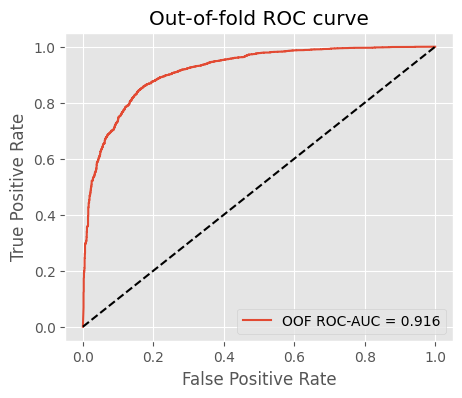

In [49]:
# Out-of-fold ROC
y_true_all = np.concatenate([item["y_true"] for item in fold_artifacts])
y_score_all = np.concatenate([item["y_score"] for item in fold_artifacts])

overall_auc = roc_auc_score(y_true_all, y_score_all)
fpr, tpr, _ = roc_curve(y_true_all, y_score_all)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"OOF ROC-AUC = {overall_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Out-of-fold ROC curve")
plt.legend()
plt.show()

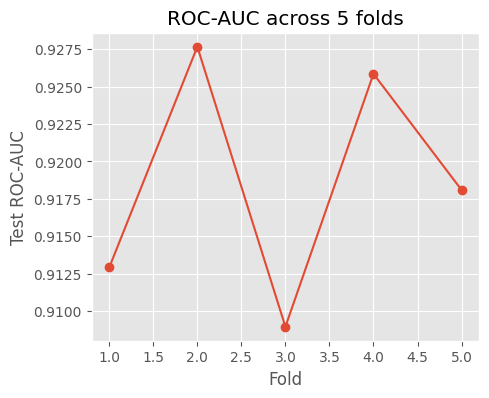

In [50]:
# Fold-wise ROCAUC
plt.figure(figsize=(5, 4))
plt.plot(results_df["fold"], results_df["test_roc_auc"], marker="o")
plt.xlabel("Fold")
plt.ylabel("Test ROC-AUC")
plt.title("ROC-AUC across 5 folds")
plt.show()

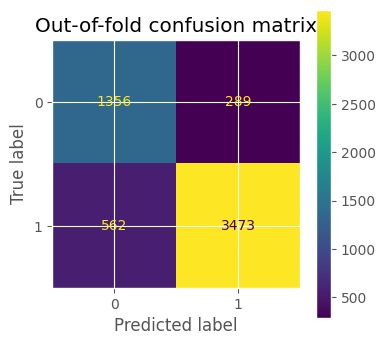

In [51]:
# Confusion matrix
y_pred_all = (y_score_all >= 0.5).astype(int)

cm = confusion_matrix(y_true_all, y_pred_all)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax)
plt.title("Out-of-fold confusion matrix")
plt.show()

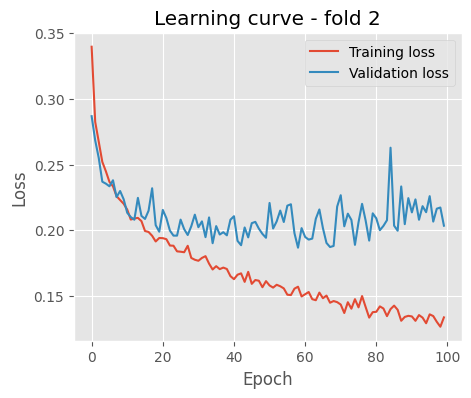

In [52]:
# Learning curve from the best fold
best_fold_idx = results_df["test_roc_auc"].idxmax()
best_fold_number = int(results_df.loc[best_fold_idx, "fold"])

best_fold_artifact = None
for item in fold_artifacts:
    if item["fold"] == best_fold_number:
        best_fold_artifact = item
        break

history = best_fold_artifact["history"]

plt.figure(figsize=(5, 4))
plt.plot(history["train_loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Learning curve - fold {best_fold_number}")
plt.legend()
plt.show()

### Discussion

I evaluated the FFNN using 5-fold stratified cross-validation, so each sample was used once as test data while preserving class balance across folds. Within each fold, I used a separate validation split for Bayesian hyperparameter optimisation and early stopping. `gp_minimize` implements Bayesian optimisation using a Gaussian-based approach.

## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

In [27]:
# LLM usage declaration
#
# I used ChatGPT-5.4 to help me:
# 1. explain and fixing errors,
# 2. refine code documentations,
# 3. explain machine-learning concepts such as ROC-AUC.
#
# TO ensure ethical use:
# I did not use LLM to generate any code from scratch;
# I validated all generated code fixes and explanations manually before using them.

## ☘️ Final word

Good luck building your own model! We hope that you enjoyed the course and exercises. Dive deeper into the aspects that caught your interest. A useful starting point may be the [Resources](https://aronwalsh.github.io/MLforMaterials/Resources.html) page.

Remember that submission is on Blackboard and you should upload both the completed Juypter Notebook (`.ipynb` file), as well as your recorded narrated presentation (maximum 5 minutes; see guides on using [Zoom](https://www.youtube.com/watch?v=H9qhoAIzW3E) or [Powerpoint](https://www.youtube.com/watch?v=Y5dgwwa5XRA) for this purpose).